# Linear Regression  Exercise

---
---
---
## Complete the tasks in bold

**TASK: Run the cells under the Imports and Data section to make sure you have imported the correct general libraries as well as the correct datasets. Later on you may need to run further imports from scikit-learn.**

### Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Data

In [220]:
df = pd.read_csv("AMES_Final_DF.csv")

In [221]:
df.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0,0,0,0,1,0,0,0,1,0
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Columns: 274 entries, Lot Frontage to Sale Condition_Partial
dtypes: float64(11), int64(263)
memory usage: 6.1 MB


**TASK: The label we are trying to predict is the SalePrice column. Separate out the data into X features and y labels**

In [224]:
X = df.drop('SalePrice',axis=1)
y = df['SalePrice']

**TASK: Use scikit-learn to split up X and y into a training set and test set. Since we will later be using a Grid Search strategy, set your test proportion to 10%. To get the same data split as the solutions notebook, you can specify random_state = 101**

In [226]:
from sklearn.model_selection import train_test_split

In [227]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

**TASK: The dataset features has a variety of scales and units. For optimal regression performance, scale the X features. Take carefuly note of what to use for .fit() vs what to use for .transform()**

In [229]:
from sklearn.preprocessing import StandardScaler

In [230]:
scaler = StandardScaler()

In [231]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [232]:
scaled_X_train

array([[-0.8384808 , -0.50803335, -0.05639001, ..., -0.13038998,
         0.46443986, -0.30126134],
       [-1.03015138, -0.50803335,  1.35711957, ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 1.26989557,  0.06576361,  0.65036478, ..., -0.13038998,
         0.46443986, -0.30126134],
       ...,
       [-0.45513964, -0.42320424, -0.05639001, ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.07195445, -0.42000314, -0.7631448 , ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.0880722 ,  0.30477899,  1.35711957, ..., -0.13038998,
         0.46443986, -0.30126134]])

In [233]:
scaled_X_test

array([[ 0.24211099, -0.51696976, -0.7631448 , ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.79071912,  0.43175591,  2.06387436, ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.5511309 ,  0.04829094, -0.7631448 , ..., -0.13038998,
        -2.15313128,  3.31937718],
       ...,
       [ 1.46156615,  0.74066194,  0.65036478, ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.93447206,  0.42215261,  2.06387436, ..., -0.13038998,
         0.46443986, -0.30126134],
       [ 0.02403681, -0.17338515,  0.65036478, ..., -0.13038998,
         0.46443986, -0.30126134]])

- fit_transform(X_train): Learns scaling parameters from training data and applies the scaling.

- transform(X_test): Applies the same scaling (from training data) to the test set — no learning happens here.

**TASK: Fit the data using a Linear Regression Model**

### Linear 

In [237]:
from sklearn.linear_model import LinearRegression

In [238]:
model = LinearRegression()

In [239]:
model.fit(scaled_X_train,y_train)

LinearRegression()


**TASK: Evaluate your model's performance on the unseen 10% scaled test set.**

In [241]:
test_predictions = model.predict(scaled_X_test)

In [242]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [243]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [244]:
MAE

14592.574380071363

In [245]:
MSE

435507080.9039939

In [246]:
RMSE

20868.806408225504


**TASK: Repeat the above steps using Polynomial Regression and Regularization.**
**Note: Only Try one Polynomial Degree and one regularization technique.**

### Polynomial

In [249]:
from sklearn.preprocessing import PolynomialFeatures

In [250]:
polynomial_converter = PolynomialFeatures(degree=2)

In [251]:
poly_features = polynomial_converter.fit_transform(X)

In [252]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.10, random_state=101)

In [253]:
scaler = StandardScaler()

In [254]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [255]:
model = LinearRegression()

In [256]:
model.fit(scaled_X_train,y_train)

LinearRegression()


**TASK: Evaluate your model's performance on the unseen 10% scaled test set.**

In [258]:
test_predictions = model.predict(scaled_X_test)

In [259]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [260]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [261]:
MAE

604125280190203.6

In [262]:
MSE

9.654566087580478e+29

In [263]:
RMSE

982576515472483.6

### Regularization

In [265]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

In [266]:
scaler = StandardScaler()

In [267]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [268]:
from sklearn.linear_model import LassoCV

In [269]:
lasso_cv_model = LassoCV(max_iter=100000,alphas=(0.1, 1.0, 10.0, 50, 100, 150, 200))

In [270]:
lasso_cv_model.fit(scaled_X_train,y_train)

LassoCV(alphas=(0.1, 1.0, 10.0, 50, 100, 150, 200), max_iter=100000)

In [271]:
lasso_cv_model.alpha_

150.0

In [272]:
test_predictions = lasso_cv_model.predict(scaled_X_test)

In [273]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [274]:
MAE

14195.033797515902

In [275]:
MSE

423207075.63988507

In [276]:
RMSE

20571.997366320196

## Great work!

----

In [278]:
from sklearn.linear_model import Lasso

In [279]:
alphas_values = range(100, 200, 2)  
mae_scores = []

for a in alphas_values:
    model = Lasso(max_iter=100000, alpha=a)
    
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)


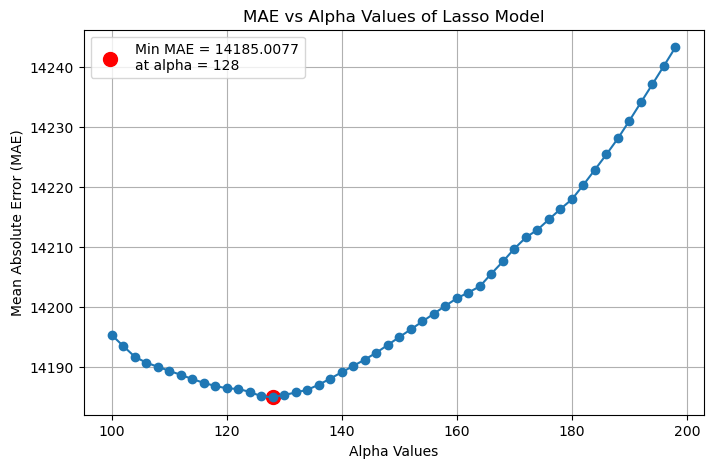

In [280]:
min_mae = min(mae_scores)
min_index = mae_scores.index(min_mae)
best_alpha = alphas_values[min_index]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(alphas_values, mae_scores, marker='o', linestyle='-')
plt.scatter(best_alpha, min_mae, color='red', s=100, label=f"Min MAE = {min_mae:.4f}\nat alpha = {best_alpha}")
plt.xlabel('Alpha Values')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE vs Alpha Values of Lasso Model')
plt.grid(True)
plt.legend()
plt.show()


In [281]:
from sklearn.linear_model import Ridge

In [282]:
alphas_values = np.arange(30, 80, 1)  
mae_scores = []

for a in alphas_values:
    model = Ridge(max_iter=100000, alpha=a)
    
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)


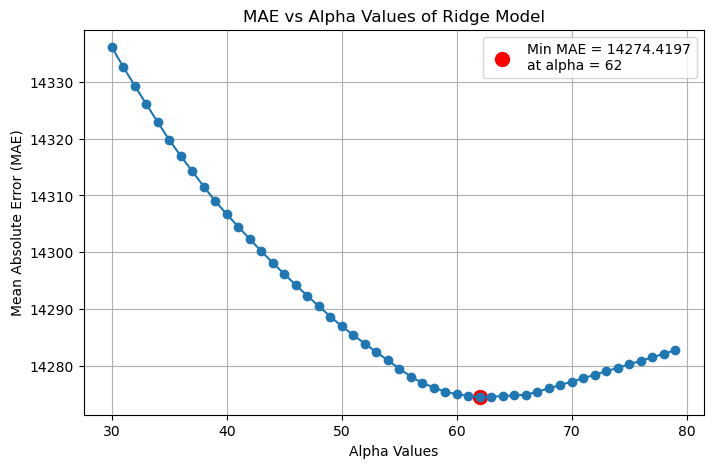

In [283]:
min_mae = min(mae_scores)
min_index = mae_scores.index(min_mae)
best_alpha = alphas_values[min_index]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(alphas_values, mae_scores, marker='o', linestyle='-')
plt.scatter(best_alpha, min_mae, color='red', s=100, label=f"Min MAE = {min_mae:.4f}\nat alpha = {best_alpha}")
plt.xlabel('Alpha Values')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE vs Alpha Values of Ridge Model')
plt.grid(True)
plt.legend()
plt.show()
